FIRST 5 ROWS
   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0              40   United-

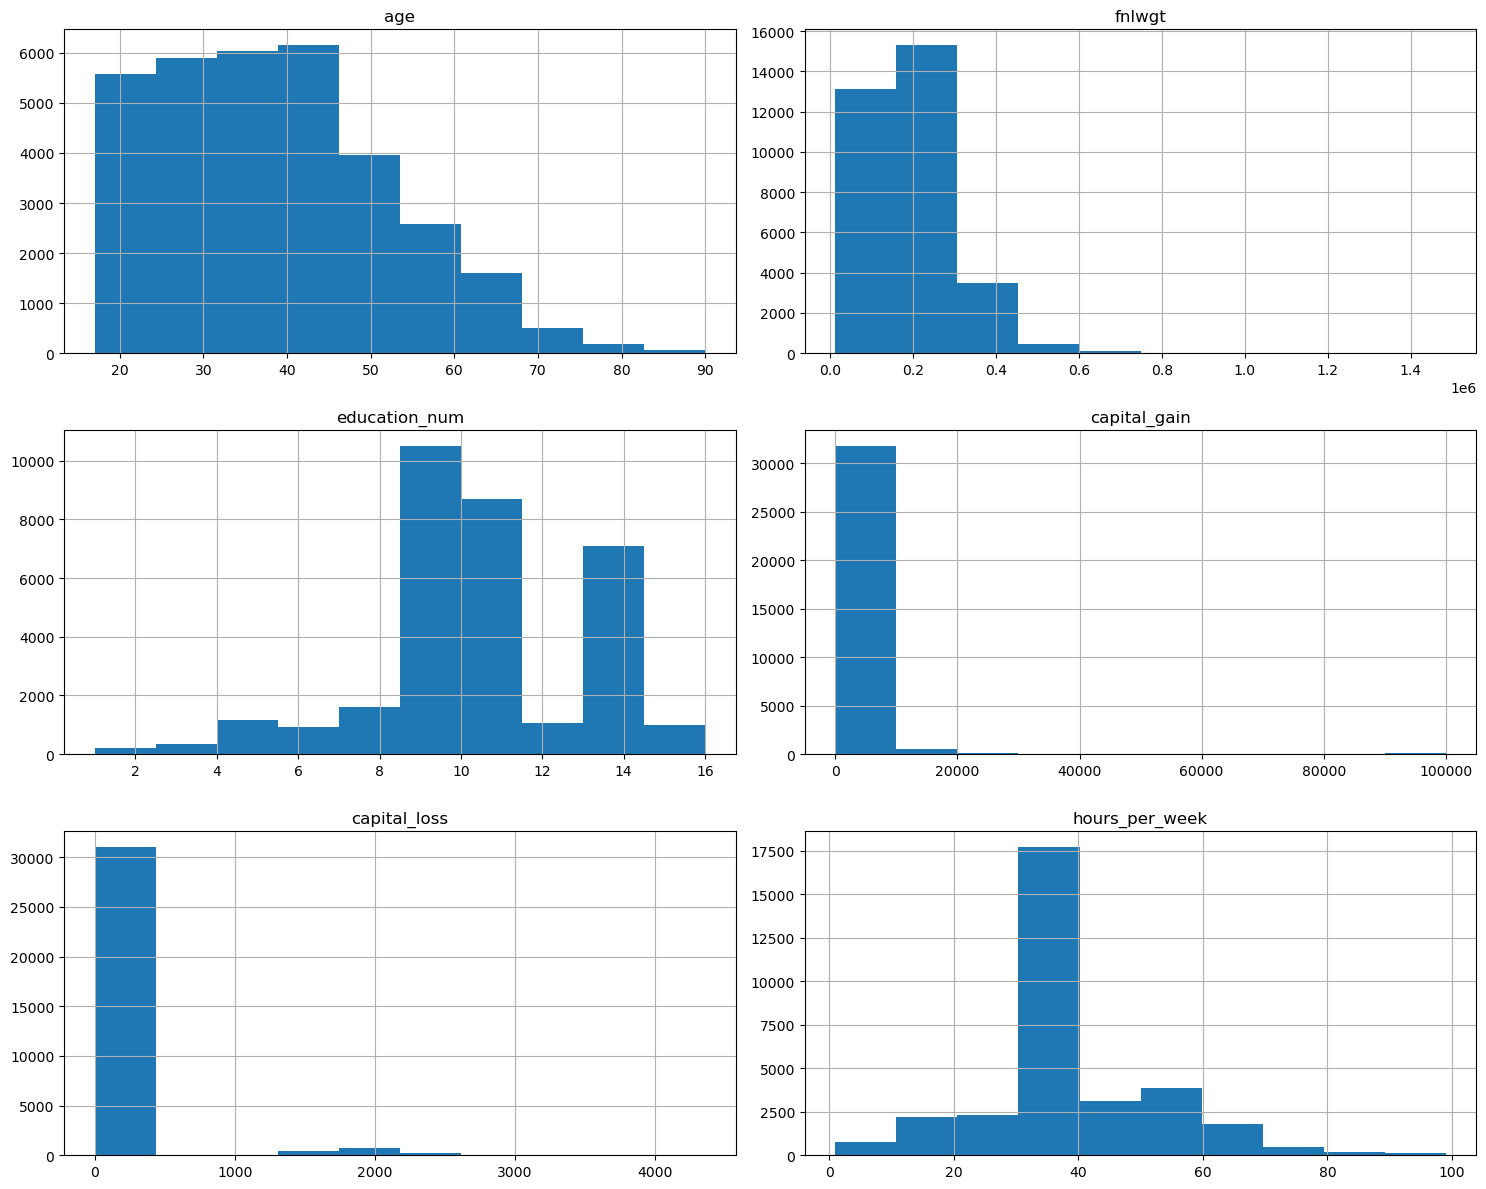


NUMERICAL COLUMNS
Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

CATEGORICAL COLUMNS
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

STANDARD SCALED DATA
        age         workclass    fnlwgt  education  education_num  \
0  0.030671         State-gov -1.063611  Bachelors       1.134739   
1  0.837109  Self-emp-not-inc -1.008707  Bachelors       1.134739   
2 -0.042642           Private  0.245079    HS-grad      -0.420060   
3  1.057047           Private  0.425801       11th      -1.197459   
4 -0.775768           Private  1.408176  Bachelors       1.134739   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Han

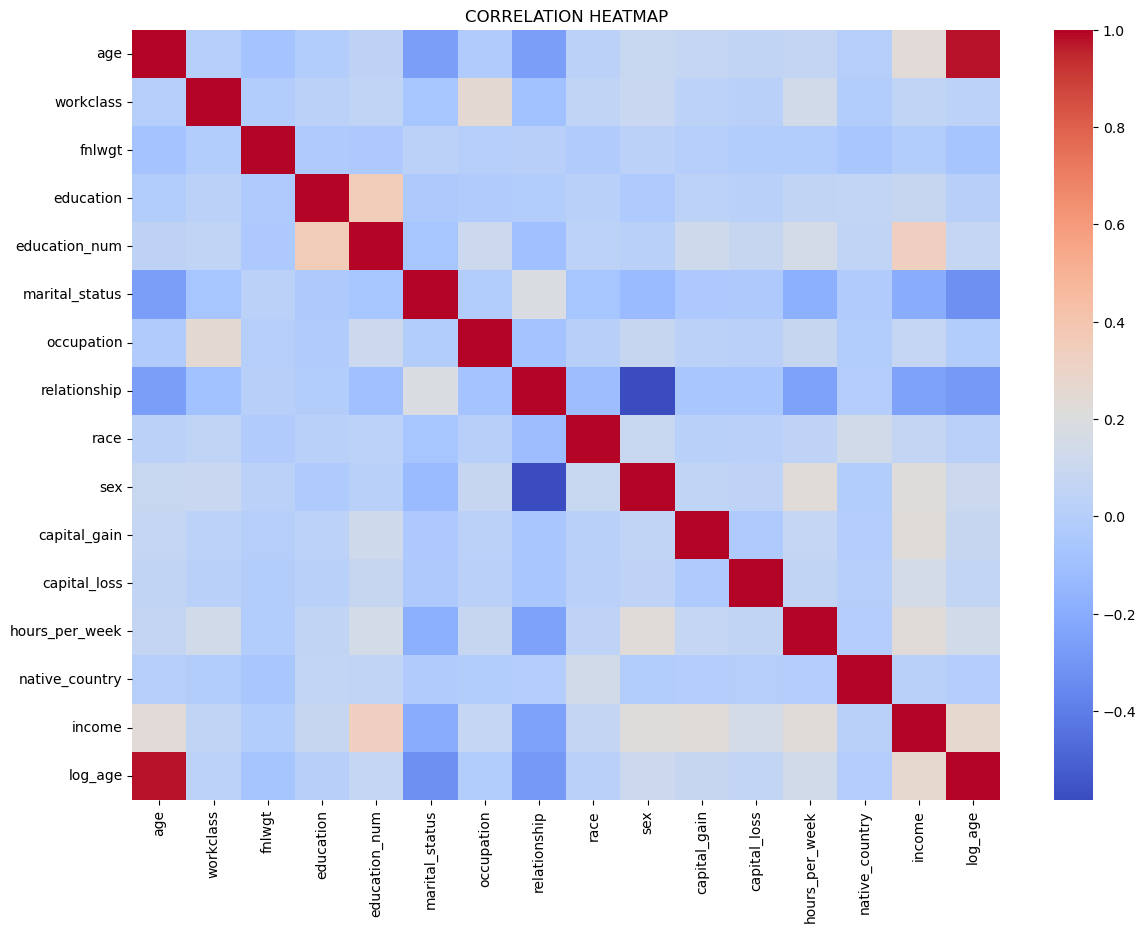


DATA PREPROCESSING COMPLETED SUCCESSFULLY

FINAL DATASET SHAPE
(32561, 16)


In [3]:
# =========================================================
# DATA PREPROCESSING & FEATURE ENGINEERING PROJECT
# COMPLETE WORKING JUPYTER NOTEBOOK CODE
# =========================================================

# =========================================================
# STEP 1 - IMPORT LIBRARIES
# =========================================================

# Used for data handling
import pandas as pd
import numpy as np

# Used for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Used for preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

# =========================================================
# STEP 2 - LOAD DATASET
# =========================================================

# Load dataset
# Make sure CSV file is in same folder as notebook

df = pd.read_csv("C:\\Users\\gagan\\Downloads\\Data Trasformation\\adult_with_headers (1).csv")

# Display first 5 rows
print("FIRST 5 ROWS")
print(df.head())

# =========================================================
# STEP 3 - DATA EXPLORATION
# =========================================================

# Shape of dataset
print("\nDATASET SHAPE")
print(df.shape)

# Column names
print("\nCOLUMN NAMES")
print(df.columns)

# Data types
print("\nDATA TYPES")
print(df.dtypes)

# Dataset information
print("\nDATASET INFO")
print(df.info())

# Summary statistics
print("\nSUMMARY STATISTICS")
print(df.describe())

# =========================================================
# STEP 4 - CHECK MISSING VALUES
# =========================================================

print("\nMISSING VALUES BEFORE CLEANING")
print(df.isnull().sum())

# =========================================================
# STEP 5 - HANDLE MISSING VALUES
# =========================================================

# Replace ? with NaN
df = df.replace("?", np.nan)

# Remove extra spaces from text columns
for col in df.select_dtypes(include='object').columns:
    
    df[col] = df[col].str.strip()

# Fill missing categorical values using mode
for col in df.select_dtypes(include='object').columns:
    
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

# Fill missing numerical values using median
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    
    df[col] = df[col].fillna(
        df[col].median()
    )

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# =========================================================
# STEP 6 - HISTOGRAMS
# =========================================================

df.hist(figsize=(15, 12))

plt.tight_layout()

plt.show()

# =========================================================
# STEP 7 - IDENTIFY NUMERICAL & CATEGORICAL COLUMNS
# =========================================================

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols = df.select_dtypes(include='object').columns

print("\nNUMERICAL COLUMNS")
print(num_cols)

print("\nCATEGORICAL COLUMNS")
print(cat_cols)

# =========================================================
# STEP 8 - STANDARD SCALING
# =========================================================

# Create scaler object
standard_scaler = StandardScaler()

# Create copy of dataframe
df_standard_scaled = df.copy()

# Apply scaling only to numerical columns
df_standard_scaled[num_cols] = standard_scaler.fit_transform(
    df_standard_scaled[num_cols]
)

print("\nSTANDARD SCALED DATA")
print(df_standard_scaled.head())

# =========================================================
# STEP 9 - MIN MAX SCALING
# =========================================================

# Create scaler object
minmax_scaler = MinMaxScaler()

# Create copy of dataframe
df_minmax_scaled = df.copy()

# Apply MinMax scaling
df_minmax_scaled[num_cols] = minmax_scaler.fit_transform(
    df_minmax_scaled[num_cols]
)

print("\nMIN MAX SCALED DATA")
print(df_minmax_scaled.head())

# =========================================================
# STEP 10 - ONE HOT ENCODING
# =========================================================

# Find categorical columns having less than 5 unique values

small_cat_cols = []

for col in cat_cols:
    
    if df[col].nunique() < 5:
        
        small_cat_cols.append(col)

print("\nCOLUMNS FOR ONE HOT ENCODING")
print(small_cat_cols)

# Apply One Hot Encoding

df_onehot = pd.get_dummies(
    df,
    columns=small_cat_cols
)

print("\nONE HOT ENCODED DATA")
print(df_onehot.head())

# =========================================================
# STEP 11 - LABEL ENCODING
# =========================================================

# Create LabelEncoder object
label_encoder = LabelEncoder()

# Create copy of dataframe
df_label = df.copy()

# Apply Label Encoding to columns with >= 5 categories

for col in cat_cols:
    
    if df_label[col].nunique() >= 5:
        
        df_label[col] = label_encoder.fit_transform(
            df_label[col]
        )

print("\nLABEL ENCODED DATA")
print(df_label.head())

# =========================================================
# STEP 12 - FEATURE ENGINEERING
# =========================================================

# New Feature 1
# Combine capital gain and capital loss

if 'capital-gain' in df.columns and 'capital-loss' in df.columns:
    
    df['capital_total'] = (
        df['capital-gain'] +
        df['capital-loss']
    )

# New Feature 2
# Hours worked according to age

if 'hours-per-week' in df.columns and 'age' in df.columns:
    
    df['hours_per_age'] = (
        df['hours-per-week'] /
        (df['age'] + 1)
    )

print("\nFEATURE ENGINEERING")
print(df.head())

# =========================================================
# STEP 13 - LOG TRANSFORMATION
# =========================================================

# Apply log transformation on age column

if 'age' in df.columns:
    
    df['log_age'] = np.log1p(df['age'])

print("\nLOG TRANSFORMED AGE")
print(df[['age', 'log_age']].head())

# =========================================================
# STEP 14 - CORRELATION HEATMAP
# =========================================================

# Create copy for heatmap
df_heatmap = df.copy()

# Convert categorical columns into numbers

for col in df_heatmap.select_dtypes(include='object').columns:
    
    le = LabelEncoder()
    
    df_heatmap[col] = le.fit_transform(
        df_heatmap[col]
    )

# Plot heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    df_heatmap.corr(),
    cmap='coolwarm'
)

plt.title("CORRELATION HEATMAP")

plt.show()

# =========================================================
# STEP 15 - FINAL OUTPUT
# =========================================================

print("\nDATA PREPROCESSING COMPLETED SUCCESSFULLY")

print("\nFINAL DATASET SHAPE")
print(df.shape)